In [56]:
#import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score,f1_score,auc,roc_curve

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
bank_data = pd.read_csv("Bank_Personal_Loan_Modelling.csv")
bank_data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
#Zip code is categorical, though the value is numerical it will impact on the regression model.
#hence finding out the unique values of zip code(467) and replacing them with the numerical intergers from 1 to 467.
#coverted each unique zip code to an interger value. Total 467 unique zip codes.

labels = bank_data['ZIP Code'].unique()
replace_zip = {'ZIP Code' : {k: v for k,v in zip(labels,list(range(1,len(labels)+1)))}}

In [5]:
bank_data.replace(replace_zip,inplace=True)
bank_data.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,1,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,2,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,3,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,4,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,5,4,1.0,2,0,0,0,0,0,1


In [6]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
#All are numerical variables and there are no missing values

In [8]:
bank_data.shape

(5000, 14)

### 1. Read the column description and ensure you understand each attribute well

In [9]:
bank_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,149.560000,126.123012,1.0,39.00,115.0,240.00,467.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### 2. Study the data distribution in each attribute, share your findings. (5 points)

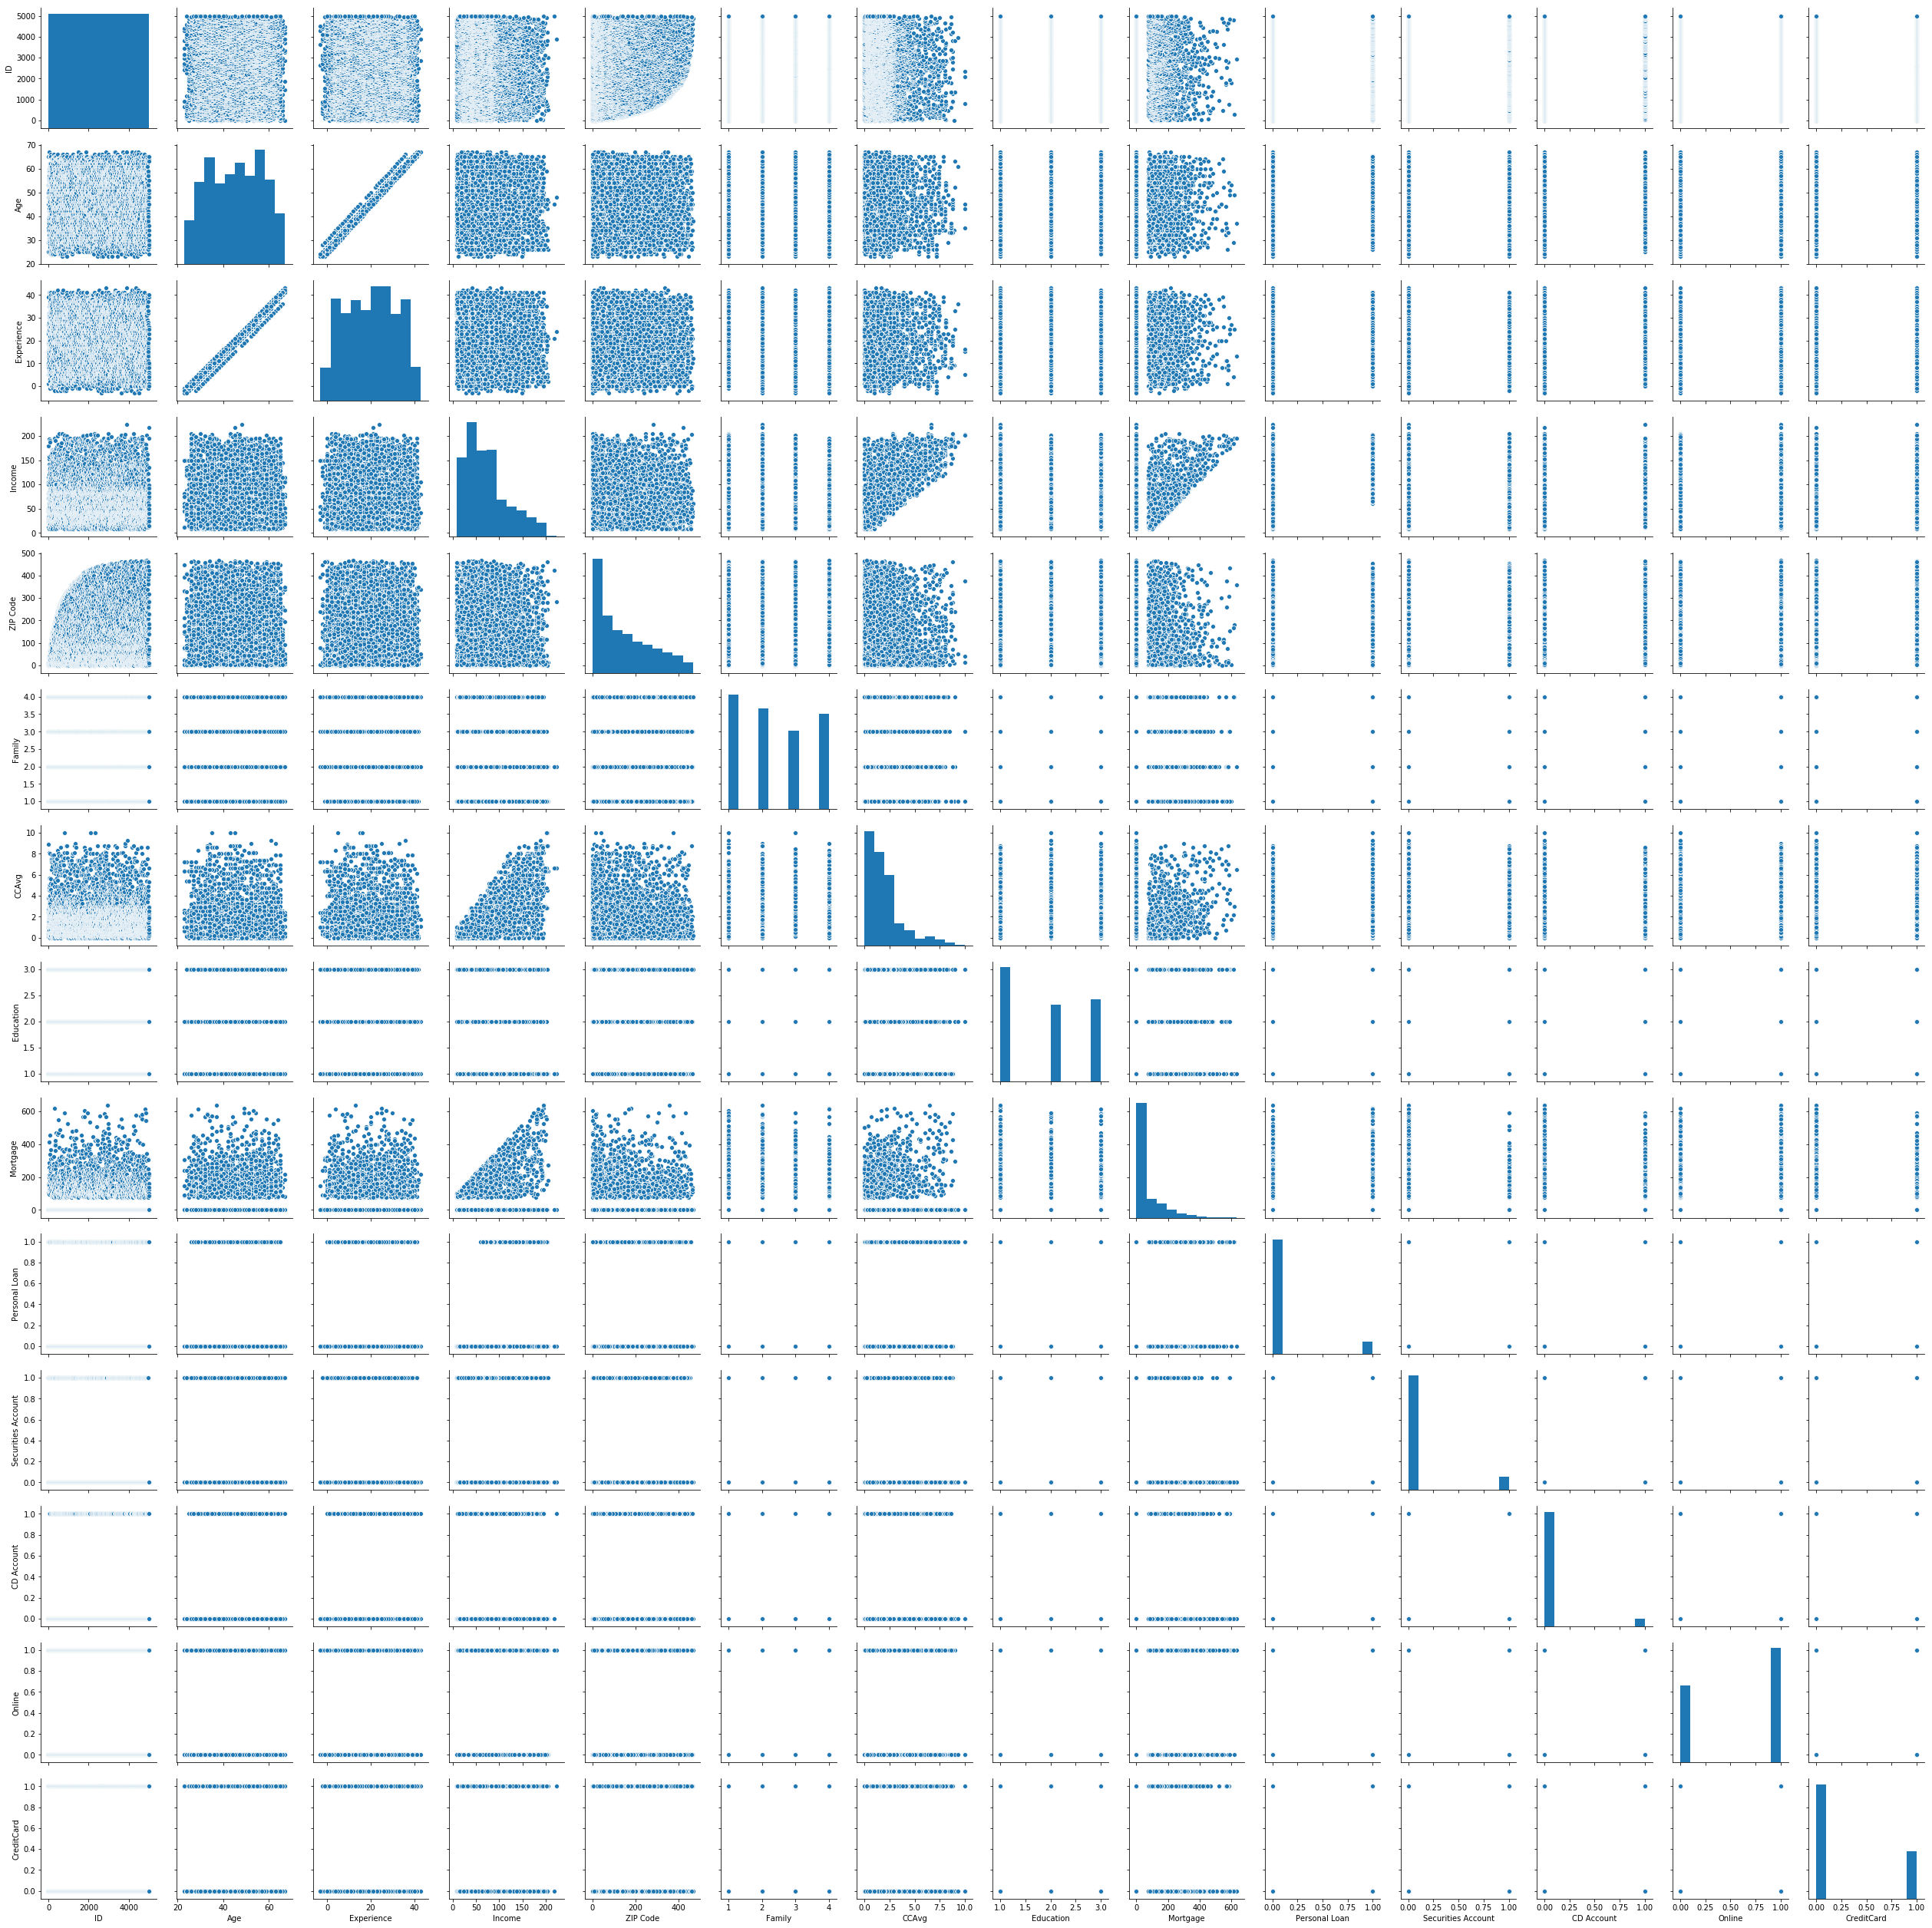

In [10]:
sns.pairplot(bank_data)

In [12]:
# The relation between age and experince is linear, even it is seen in with the correlation value which is close to 1(0.99)
# The attributes look like they may have an exponential distribution like Income,CCAvg and Mortage
# Higher Age/income people have Mortages while lower age/income people does not.
# The attributes which look normally distributed age and experince
# Mean and Median for the attributes age and experince is almost the same which shows strong coorelation.
# Age mean and median is 45
# Experince mean and median is 20

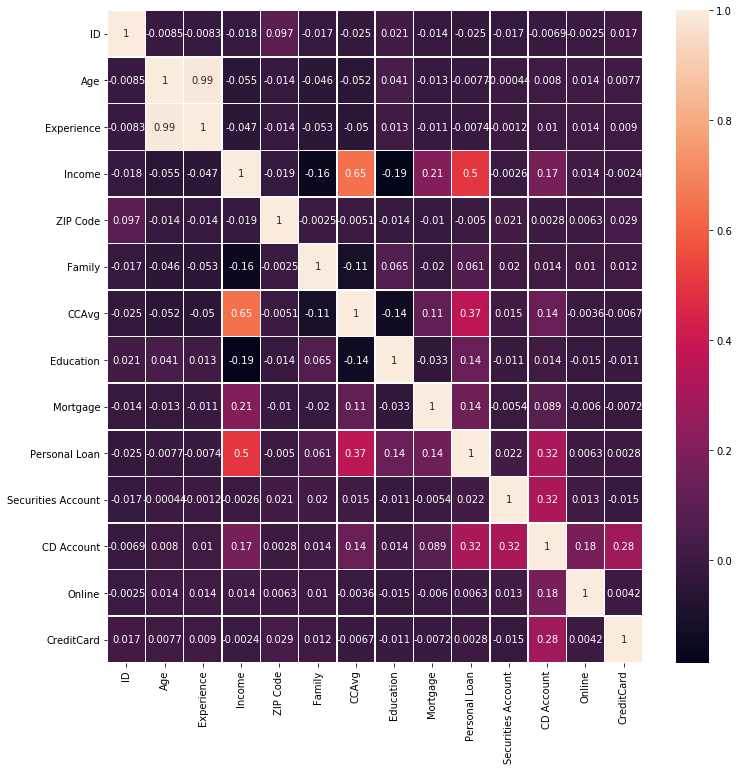

In [13]:
correlation = bank_data.corr()
fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation,annot=True,linewidths=0.5,ax=ax)

In [15]:
#strong coorelation between age and experince(almost linear).
#Since there is strong correlation of experience with age,we can drop one of the feature.

In [17]:
#Observe the independent variables variance and drop such variables having variance < 0.1.
#They will be having almost no influence on the classification.

In [20]:
np.var(bank_data)

ID                    2.083333e+06
Age                   1.313779e+02
Experience            1.314877e+02
Income                2.118680e+03
ZIP Code              1.590383e+04
Family                1.316867e+00
CCAvg                 3.053701e+00
Education             7.052390e-01
Mortgage              1.034363e+04
Personal Loan         8.678400e-02
Securities Account    9.350064e-02
CD Account            5.675184e-02
Online                2.406298e-01
CreditCard            2.075640e-01
dtype: float64

In [21]:
#removing Securities Account,CD Account as they have very less influence.
##Since there is strong correlation between age and experince,dropping the experince feature

bank_data = bank_data.drop(['Securities Account','CD Account','Experience'],axis=1)

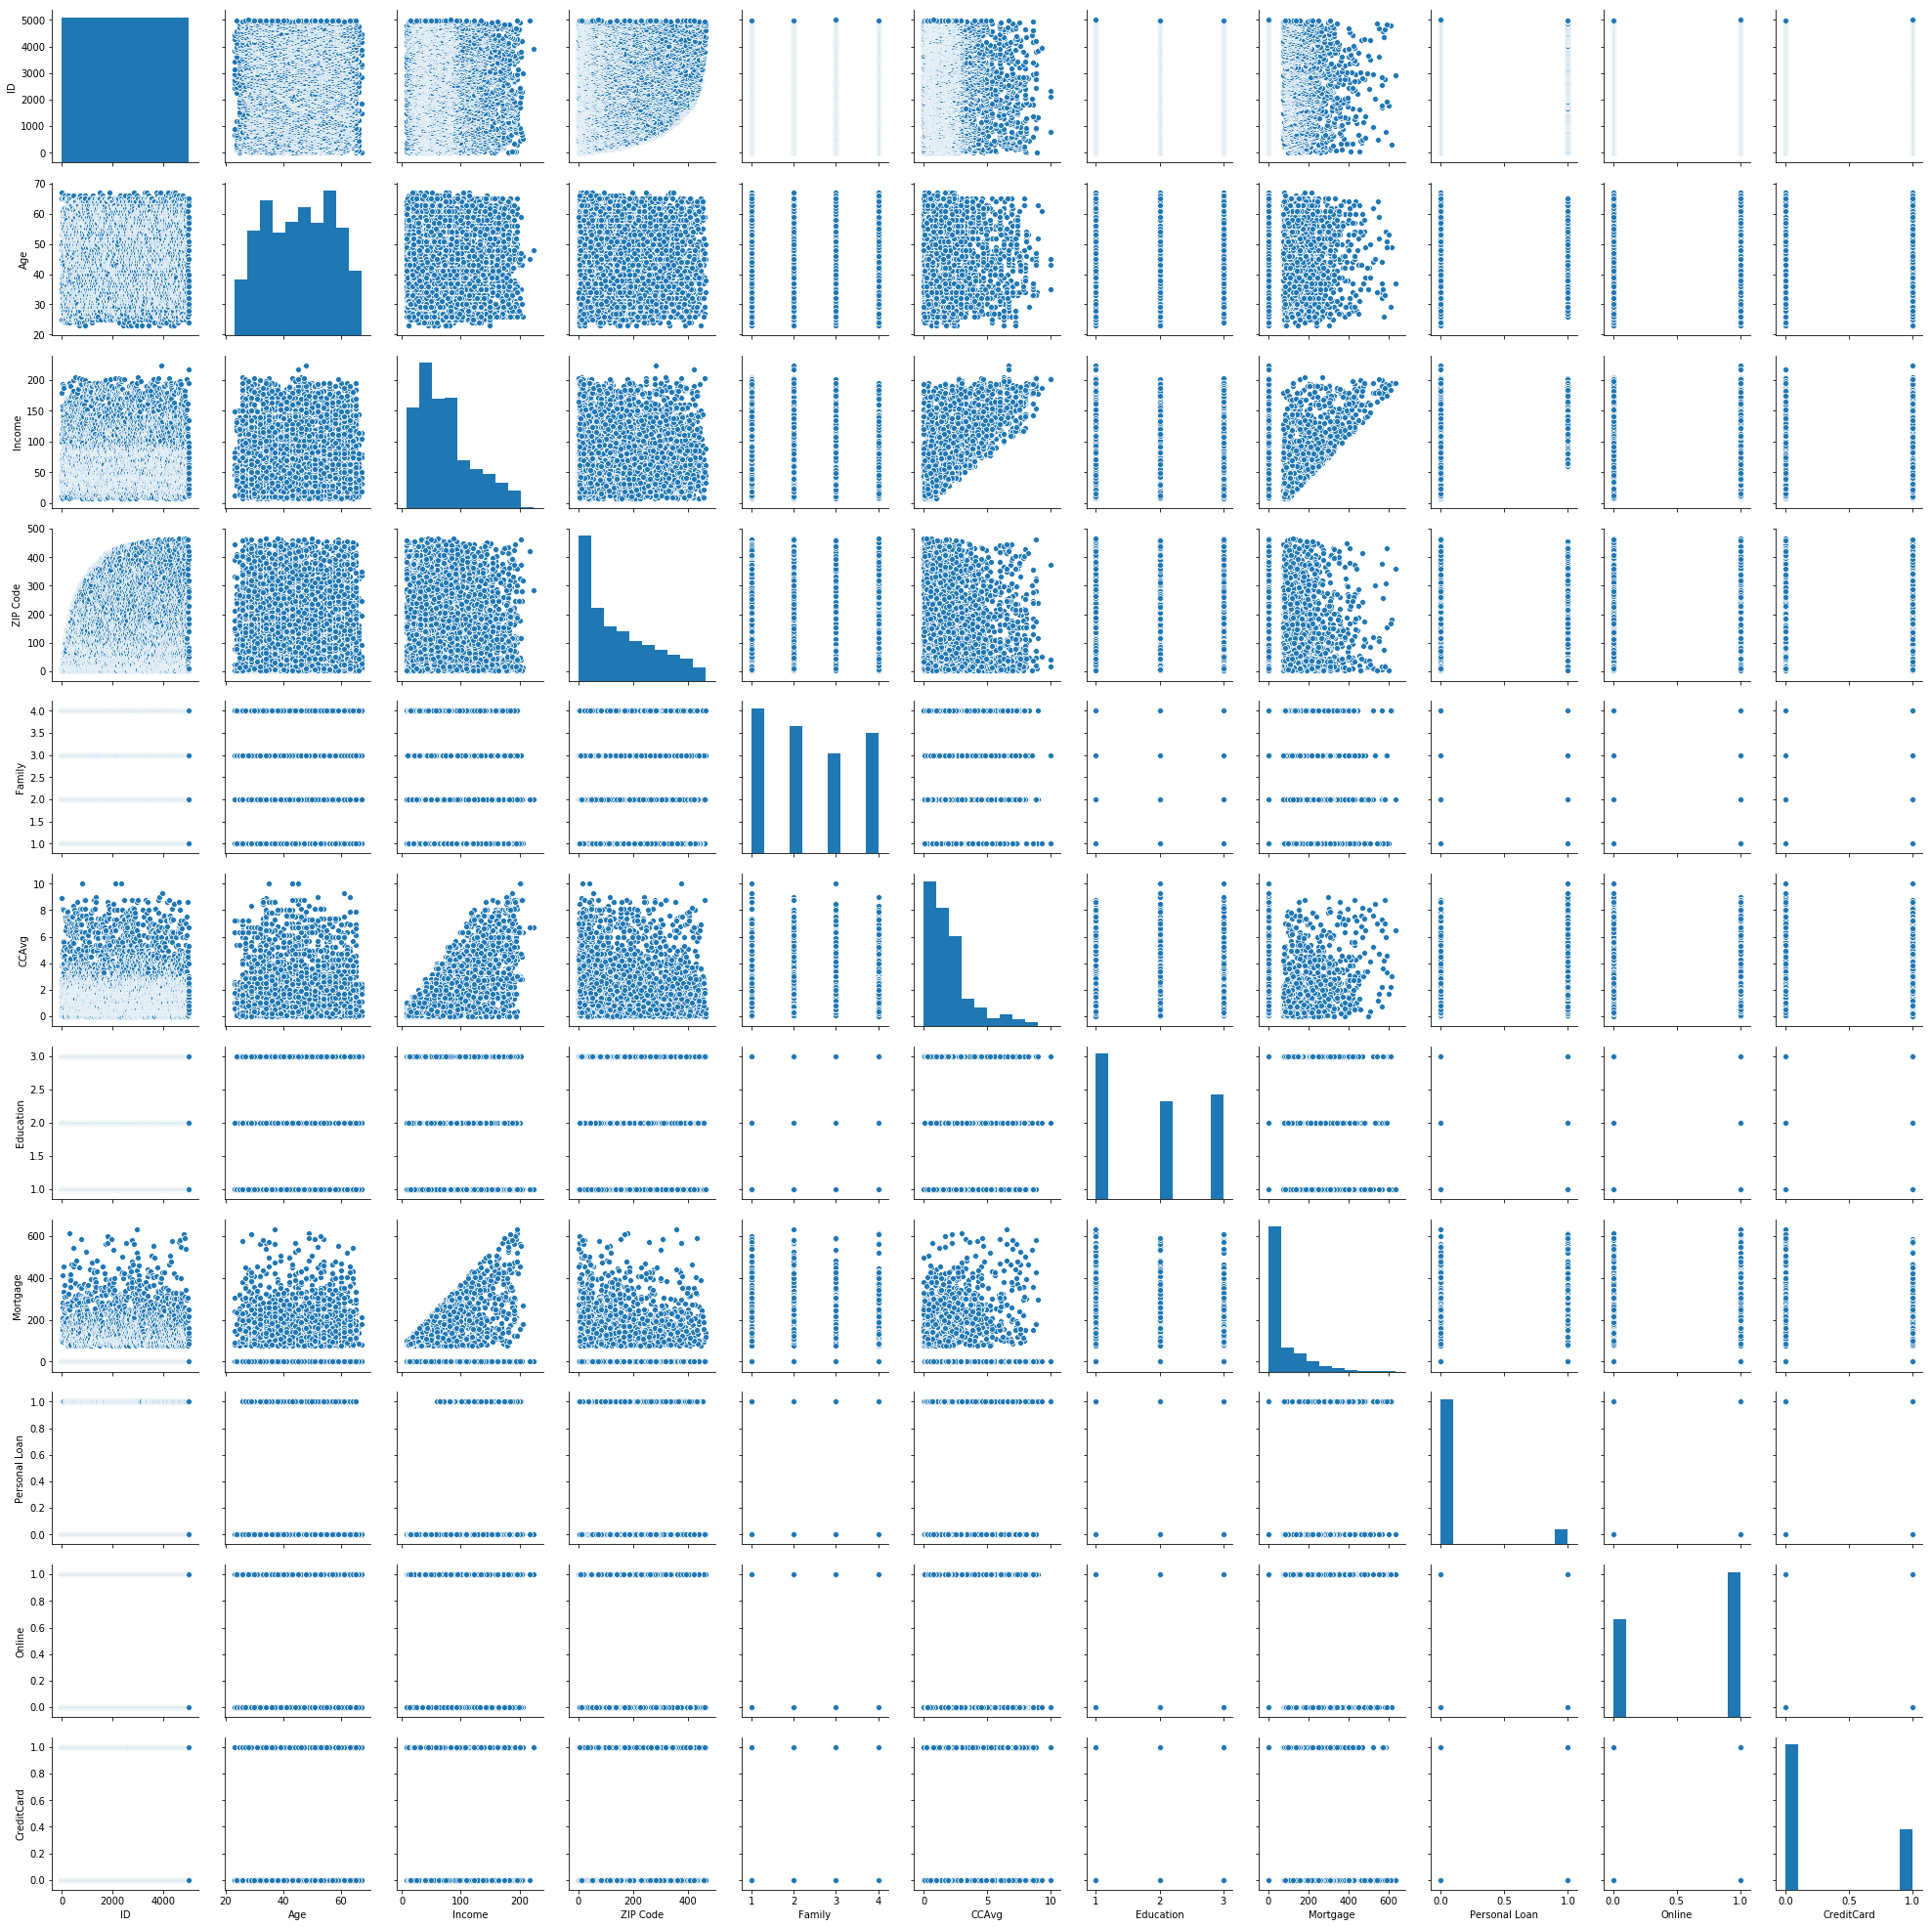

In [58]:
#pairplot after feature removel
sns.pairplot(bank_data)

### 3. Get the target column distribution. Your comments (5 points)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001ED99F6A6A0>,
      dtype=object)

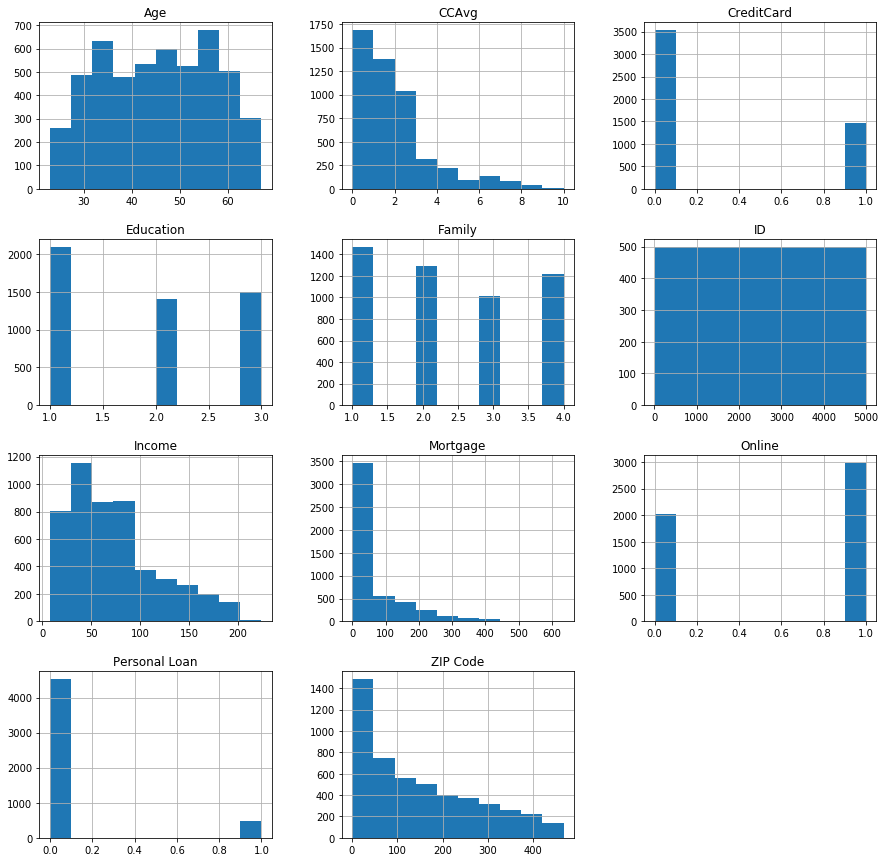

In [22]:
bank_data.hist(figsize=(15,15))

Personal Loan
0    [[AxesSubplot(0.125,0.725918;0.215278x0.154082...
1    [[AxesSubplot(0.125,0.725918;0.215278x0.154082...
dtype: object

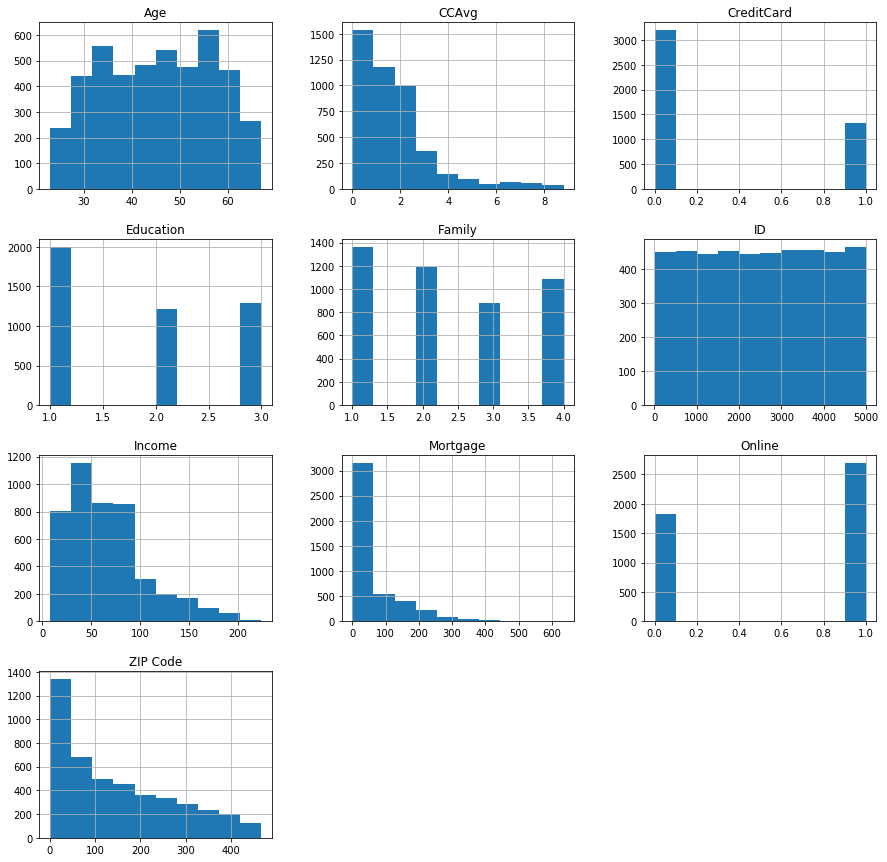

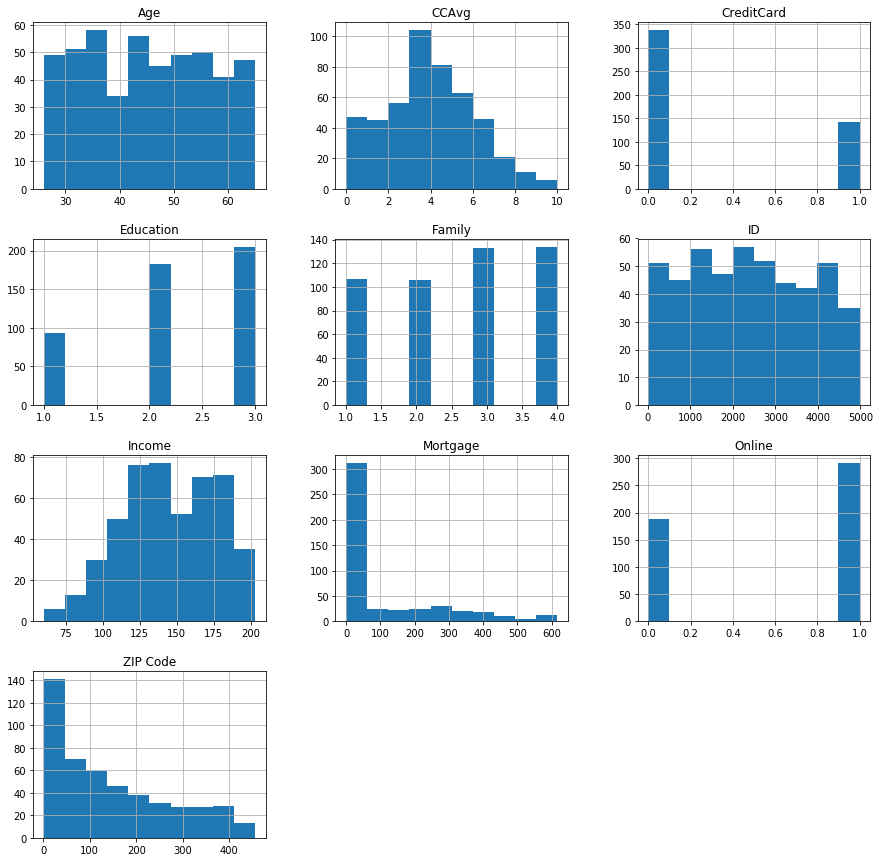

In [23]:
bank_data.groupby('Personal Loan').hist(figsize=(15,15))

In [24]:
#The attributes Age,CCAvg and Income have a uniform distrubution with the target column (personal Loan)
#The attributes look like they may have an exponential distribution like Income,CCAvg and Mortage
#We can say the attributes Income driving the personal loan.It has the strong coorelation also of 0.5

### 4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [25]:
X = bank_data.drop('Personal Loan',axis=1)
y = bank_data['Personal Loan']

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=7)

In [27]:
print('Shape of train data:',X_train.shape)
print('Shape of test data:',X_test.shape)

Shape of train data: (3500, 10)
Shape of test data: (1500, 10)


### 5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

In [28]:
model1 = LogisticRegression()
model1.fit(X_train,y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [29]:
#defining a function for Logistic and Naive bayes which does the following:
#Calculates the accuraccy ,precision,recall,f1 score for both train and test data with optimal and default thresholds

def modeldesign(X_train,X_test,y_train,y_test,model):
    #unoptimized using threshold 0.5
    #train predictions
    trainpreds = np.where(model.predict_proba(X_train)[:,1] > 0.5 ,1,0)
    trainAccuracy = accuracy_score(y_train,trainpreds)
    trainRecall = recall_score(y_train,trainpreds)
    trainPrecision = precision_score(y_train,trainpreds)
    trainF1score = f1_score(y_train,trainpreds)

    trainResults = [X_train.shape[0],0.5,trainAccuracy,trainRecall,trainPrecision,trainF1score]


    #test predictions
    testpreds = np.where(model.predict_proba(X_test)[:,1] > 0.5 ,1,0)
    testAccuracy = accuracy_score(y_test,testpreds)
    testRecall = recall_score(y_test,testpreds)
    testPrecision = precision_score(y_test,testpreds)
    testF1score = f1_score(y_test,testpreds)

    testResults = [X_test.shape[0],0.5,testAccuracy,testRecall,testPrecision,testF1score]

    #### Optimize probability threshold and calculate performance numbers
    y_predictprob = model.predict_proba(X_train)
    fpr,tpr,thresholds = roc_curve(y_train,y_predictprob[::,1])
    optimalTh = 0
    optimalF1 = 0

    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th,1,0)
        f1score = f1_score(y_train,preds)
        if (optimalF1 < f1score):
            optimalF1 = f1score
            optimalTh = th

    resultsDf = pd.DataFrame(index=["datasize","optimalTh","Accuracy","Recall","Precision","F1Score"])

    #optimal Train predictions

    opttrainpreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh ,1,0)
    opttrainAccuracy = accuracy_score(y_train,opttrainpreds)
    opttrainRecall = recall_score(y_train,opttrainpreds)
    opttrainPrecision = precision_score(y_train,opttrainpreds)
    opttrainF1score = f1_score(y_train,opttrainpreds)

    opttrainResults = [X_train.shape[0],optimalTh,opttrainAccuracy,opttrainRecall,opttrainPrecision,opttrainF1score]

    #Optimal test predictions
    opttestpreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh ,1,0)
    opttestAccuracy = accuracy_score(y_test,opttestpreds)
    opttestRecall = recall_score(y_test,opttestpreds)
    opttestPrecision = precision_score(y_test,opttestpreds)
    opttestF1score = f1_score(y_test,opttestpreds)

    opttestResults = [X_test.shape[0],optimalTh,opttestAccuracy,opttestRecall,opttestPrecision,opttestF1score]

    resultsDf['unoptimalTrainResults'] = trainResults
    resultsDf['unoptimalTestResults']  = testResults
    resultsDf['optimalTrainResults']   = opttrainResults
    resultsDf['optimalTestResults']    = opttestResults
    return resultsDf.round(2)

In [30]:
y_predict = model1.predict(X_test)
LRCM = confusion_matrix(y_test,y_predict)

In [33]:
print("Logistic Regression model")
LRModel = modeldesign(X_train,X_test,y_train,y_test,model1)
LRModel

Logistic Regression model


,unoptimalTrainResults,unoptimalTestResults,optimalTrainResults,optimalTestResults
datasize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.27,0.27
Accuracy,0.93,0.94,0.93,0.93
Recall,0.44,0.51,0.73,0.74
Precision,0.75,0.80,0.61,0.60
F1Score,0.56,0.62,0.66,0.66


In [34]:
model2 = GaussianNB()
model2.fit(X_train,y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [35]:
y_predict = model2.predict(X_test)
NBCM = confusion_matrix(y_test,y_predict)

In [36]:
print("Naive's Bayes model")
NBModel = modeldesign(X_train,X_test,y_train,y_test,model2)
NBModel

Naive's Bayes model


,unoptimalTrainResults,unoptimalTestResults,optimalTrainResults,optimalTestResults
datasize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.10,0.10
Accuracy,0.90,0.90,0.88,0.88
Recall,0.59,0.59,0.83,0.84
Precision,0.50,0.48,0.43,0.43
F1Score,0.54,0.53,0.57,0.57


In [37]:
# convert the features into z scores as we do not know what units / scales were used and store them in new dataframe
# It is always adviced to scale numeric attributes in models that calculate distances.

Xnew = X.apply(zscore) # convert all attributes to Z scale 
Xnew.head(5)

,ID,Age,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Online,CreditCard
0,-1.731704,-1.774417,-0.538229,-1.178015,1.397414,-0.193385,-1.049078,-0.555524,-1.216618,-0.645314
1,-1.731012,-0.029524,-0.864109,-1.170086,0.525991,-0.250611,-1.049078,-0.555524,-1.216618,-0.645314
2,-1.730319,-0.552992,-1.363793,-1.162156,-1.216855,-0.536736,-1.049078,-0.555524,-1.216618,-0.645314
3,-1.729626,-0.901970,0.569765,-1.154227,-1.216855,0.436091,0.141703,-0.555524,-1.216618,-0.645314
4,-1.728933,-0.901970,-0.625130,-1.146297,1.397414,-0.536736,0.141703,-0.555524,-1.216618,1.549632


In [38]:
X_train, X_test, y_train, y_test = train_test_split(Xnew, y, test_size=0.3, random_state=7)

In [39]:
knn = KNeighborsClassifier()

In [40]:
#Do a gridsearch to get the optimal n_neighbours value with accuracy as scoring and use that in the model
from sklearn.model_selection import GridSearchCV
parameter = {'n_neighbors':np.arange(2,10)}
GS = GridSearchCV(knn,parameter,cv=3,scoring='accuracy')
GS.fit(Xnew,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_neighbors': array([2, 3, 4, 5, 6, 7, 8, 9])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [41]:
GS.best_params_

{'n_neighbors': 3}

In [42]:
GS.best_score_

0.9502

In [43]:
#from the above results we can use n_neighbors as 3 for the best results which gives the accuracy score of 95%

In [44]:
model3 = KNeighborsClassifier(n_neighbors=3)
model3.fit(X_train,y_train)


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=3, p=2,
           weights='uniform')

In [45]:
# For every test data point, predict it's label based on 3 nearest neighbours in this model. The majority class will 
# be assigned to the test data point
predicted_labels = model3.predict(X_test)

In [46]:
model3.score(X_test,y_test)

0.95

In [47]:
KNNCM = confusion_matrix(y_test, predicted_labels)
KNNCM

array([[1357,    5],
       [  70,   68]], dtype=int64)

In [48]:
testPreds = model3.predict(X_test)

KnntestAccuracy = accuracy_score(y_test,testPreds)
KnntestRecall = recall_score(y_test,testPreds)
KnntestPrecision = precision_score(y_test,testPreds)
KnntestF1score = f1_score(y_test,testPreds)

KnnModel = pd.DataFrame(index=["Accuracy","Recall","Precision","F1Score"])
KnntestResults = [KnntestAccuracy,KnntestRecall,KnntestPrecision,KnntestF1score]

KnnModel['optimalTestResults'] = KnntestResults

KnnModel

,optimalTestResults
Accuracy,0.950000
Recall,0.492754
Precision,0.931507
F1Score,0.644550


### 6. Print the confusion matrix for all the above models (10 points)

In [49]:
print("confusion matrix for logistic regression")
LRCM

confusion matrix for logistic regression


array([[1344,   18],
       [  68,   70]], dtype=int64)

In [50]:
print("confusion matrix for Naives Bayes")
NBCM

confusion matrix for Naives Bayes


array([[1273,   89],
       [  56,   82]], dtype=int64)

In [51]:
print("confusion matrix for KNN")
KNNCM

confusion matrix for KNN


array([[1357,    5],
       [  70,   68]], dtype=int64)

### 7.Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [52]:
#Trying to merge the results of all the 3 models on the test data

LRModel['LRModelResults'] = LRModel.loc[['Accuracy','Recall','Precision','F1Score'],['optimalTestResults']]
LRModel1 = LRModel.loc[['Accuracy','Recall','Precision','F1Score'],['LRModelResults']]

NBModel['NBModelResults'] = NBModel.loc[['Accuracy','Recall','Precision','F1Score'],['optimalTestResults']]
NBModel1 = NBModel.loc[['Accuracy','Recall','Precision','F1Score'],['NBModelResults']]

KnnModel['KnnModelResults'] = KnnModel.loc[['Accuracy','Recall','Precision','F1Score'],['optimalTestResults']]
KnnModel1 = KnnModel.loc[['Accuracy','Recall','Precision','F1Score'],['KnnModelResults']]

In [53]:
ModelResults = pd.concat([LRModel1,NBModel1,KnnModel1],axis=1)
ModelResults

,LRModelResults,NBModelResults,KnnModelResults
Accuracy,0.93,0.88,0.950000
Recall,0.74,0.84,0.492754
Precision,0.60,0.43,0.931507
F1Score,0.66,0.57,0.644550


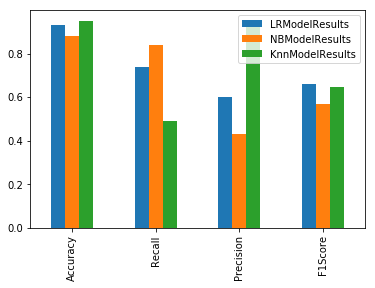

In [55]:
#plotting the bar graph to compare the metric of each model

ModelResults.plot.bar()

In [ ]:
#Accuracy:
#From the above graph we could see that the accuracy of the Logistic regression and NB are 93 and 88 respetively.
#while the KNN model has the highest accuracy of 95%

#Recall:
#For Naive's Bayes is 84% ,being the best of the three. While for KNN it is low as 49% . 
#Out of the customers identified by NB Model for personal loan, 81% of them will apply for personal loan.
#Recall talks about type 2 error,in case of KNN model the type 2 error is more.


#Precision:
#For KNN model we have 93% precision while for LR and NB it is 60% and 43% respectively.
#KNN model has a minimum Type-1 error compared to other 2 models.Out of the identified customers for personal loan
#93% are correct and who will be taking the personal loan.
#Precision talks about type - 1 error.

#F1Score:
#the F1 score takes both Recall and Precision into consideration.For the models LR and KNN its almost same(66 and 64)
#while for NB it is the lowest 57%


#Conclusion:
#Considering the above results and factors LR is the better model as it has F1 score compared to
#the other two model.Also good balance between Type 1 and Type 2 error.
